Per CMS "Telemedicine is the exchange of medical information from one site to another through electronic
communication to improve a patient’s health. Prior to March 2020, Medicare paid for these services
under limited circumstances, with telemedicine services restricted to rural or health professional
shortage areas, established patients, or certain types of providers.
In response to the COVID-19 public health emergency, telemedicine services have been expanded to
increase access to care including: lifting of geographic area restrictions with services allowed to be
delivered from patients’ home; allowing for both new and established patients; expanding eligible
services and the types of providers; and allowing for a select set of audio-only telehealth services."

The aim of this project is to explore differences in telehealth usage among various demographics over time. 

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('telehealth project/TMEDTREND_PUBLIC_260311.csv')

print(df.head())

# Get basic information about dataframe
print("\nDataframe Info:")
print(df.info())

# Get basic statistics of numerical columns
print("\nBasic Statistics:")
print(df.describe())

   Year  quarter Bene_Geo_Desc Bene_Mdcd_Mdcr_Enrl_Stus Bene_Race_Desc  \
0  2020  Overall      National                      All            All   
1  2020  Overall      National                      All            All   
2  2020  Overall      National                      All            All   
3  2020  Overall      National                      All            All   
4  2020  Overall      National                      All            All   

  Bene_Sex_Desc Bene_Mdcr_Entlmt_Stus Bene_Age_Desc Bene_RUCA_Desc  \
0           All                   All           All            All   
1           All                   All           All          Rural   
2           All                   All           All          Urban   
3           All                   All           All        Unknown   
4           All                   All          0-64            All   

   Total_Bene_TH_Elig  Total_PartB_Enrl  Total_Bene_Telehealth  Pct_Telehealth  
0          30946785.0      3.224489e+07             1

In [28]:
df_states = df[
    (df['Bene_Geo_Desc'] != 'National') & 
    (df['Bene_Geo_Desc'] != 'Missing Data') & 
    (df['quarter'] == 'Overall')  &
    (df["Bene_Mdcd_Mdcr_Enrl_Stus"] == 'All') &
    (df["Bene_Race_Desc"] == 'All') &
    (df["Bene_Sex_Desc"] == 'All') &
    (df["Bene_Mdcr_Entlmt_Stus"] == 'All') &  
    (df["Bene_Age_Desc"] == 'All') &
    (df["Bene_RUCA_Desc"] == 'All')
]


#print(df_states.shape)
#print(df_states['Bene_Geo_Desc'].value_counts())

exclude = {'Puerto Rico', 'Virgin Islands', 'Territories'}

df_states_clean = df[
    (df['quarter'] == 'Overall') &
    (df["Bene_Mdcd_Mdcr_Enrl_Stus"] == 'All') &
    (df["Bene_Race_Desc"] == 'All') &
    (df["Bene_Sex_Desc"] == 'All') &
    (df["Bene_Mdcr_Entlmt_Stus"] == 'All') &
    (df["Bene_Age_Desc"] == 'All') &
    (df["Bene_RUCA_Desc"] == 'All') &
    (~df['Bene_Geo_Desc'].isin(exclude)) &
    (df['Bene_Geo_Desc'] != 'National') &
    (df['Bene_Geo_Desc'] != 'Missing Data')
].copy()

df_states_clean['Pct_Telehealth'] = pd.to_numeric(
    df_states_clean['Pct_Telehealth'].astype(str).str.replace('%', ''),
    errors='coerce'
)
df_states_clean = df_states_clean.dropna(subset=['Pct_Telehealth'])




In [29]:
import folium
import requests

url = "https://raw.githubusercontent.com/python-visualization/folium/master/examples/data/us-states.json"
response = requests.get(url)
us_states_geo = response.json()



df_states_2024 = df_states_clean[(df_states_clean['Year'] == 2024) ].copy()

m = folium.Map(location=[37, -95], zoom_start=4)

folium.Choropleth(
    geo_data=us_states_geo,
    name='choropleth',
    data=df_states_2024,             # ← filtered
    columns=['Bene_Geo_Desc', 'Pct_Telehealth'],
    key_on='feature.properties.name',
    fill_color='YlOrRd',
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name='Telehealth Percentage (%)'
).add_to(m)

pct_dict = df_states_2024.set_index('Bene_Geo_Desc')['Pct_Telehealth'].to_dict()  # ← filtered
for feature in us_states_geo['features']:
    state = feature['properties']['name']
    feature['properties']['Pct_Telehealth'] = round(pct_dict.get(state, 0), 2)

folium.GeoJson(
    us_states_geo,
    style_function=lambda x: {'fillColor': 'transparent', 'color': 'transparent'},
    tooltip=folium.GeoJsonTooltip(
        fields=['name', 'Pct_Telehealth'],
        aliases=['State:', 'Telehealth %:'],
        localize=True
    ),
    popup=folium.GeoJsonPopup(
        fields=['name', 'Pct_Telehealth'],
        aliases=['State:', 'Telehealth %:']
    )
).add_to(m)

folium.LayerControl().add_to(m)
m


2024 was chosen as the latest year because it contained all quarterly data. 

In [30]:
import plotly.express as px

exclude = {'Puerto Rico', 'Virgin Islands', 'Territories'}
df_plot = df[~df['Bene_Geo_Desc'].isin(exclude)].copy()
df_plot['Pct_Telehealth'] = pd.to_numeric(
    df_plot['Pct_Telehealth'].astype(str).str.replace('%', ''),
    errors='coerce'
)

# Map full names to abbreviations
state_abbrev = {
    'Alabama': 'AL', 'Alaska': 'AK', 'Arizona': 'AZ', 'Arkansas': 'AR',
    'California': 'CA', 'Colorado': 'CO', 'Connecticut': 'CT', 'Delaware': 'DE',
    'Florida': 'FL', 'Georgia': 'GA', 'Hawaii': 'HI', 'Idaho': 'ID',
    'Illinois': 'IL', 'Indiana': 'IN', 'Iowa': 'IA', 'Kansas': 'KS',
    'Kentucky': 'KY', 'Louisiana': 'LA', 'Maine': 'ME', 'Maryland': 'MD',
    'Massachusetts': 'MA', 'Michigan': 'MI', 'Minnesota': 'MN', 'Mississippi': 'MS',
    'Missouri': 'MO', 'Montana': 'MT', 'Nebraska': 'NE', 'Nevada': 'NV',
    'New Hampshire': 'NH', 'New Jersey': 'NJ', 'New Mexico': 'NM', 'New York': 'NY',
    'North Carolina': 'NC', 'North Dakota': 'ND', 'Ohio': 'OH', 'Oklahoma': 'OK',
    'Oregon': 'OR', 'Pennsylvania': 'PA', 'Rhode Island': 'RI', 'South Carolina': 'SC',
    'South Dakota': 'SD', 'Tennessee': 'TN', 'Texas': 'TX', 'Utah': 'UT',
    'Vermont': 'VT', 'Virginia': 'VA', 'Washington': 'WA', 'West Virginia': 'WV',
    'Wisconsin': 'WI', 'Wyoming': 'WY'
}
df_plot['state_abbrev'] = df_plot['Bene_Geo_Desc'].map(state_abbrev)

fig = px.choropleth(
    df_plot,
    locations='state_abbrev',
    locationmode='USA-states',
    color='Pct_Telehealth',
    scope='usa',
    color_continuous_scale='YlOrRd',
    labels={'Pct_Telehealth': 'Telehealth %'},
    hover_name='Bene_Geo_Desc',
    animation_frame='Year',          # ← dropdown/slider by year
    range_color=[                    # fix scale across all years
        df_plot['Pct_Telehealth'].min(),
        df_plot['Pct_Telehealth'].max()
    ],
    title='Telehealth Percentage by State from 2020 to  2025'
)

fig.update_layout(
    geo=dict(projection_type='albers usa'),
    sliders=[{"currentvalue": {"prefix": "Year: "}}]
)

fig.show()


In [31]:
df_rurality = df[
    (df['Bene_Geo_Desc'] == 'National') & 
    (df['quarter'] == 'Overall') &
    (df["Bene_Mdcd_Mdcr_Enrl_Stus"] == 'All') &
    (df["Bene_Race_Desc"] == 'All') &
    (df["Bene_Sex_Desc"] == 'All') &
    (df["Bene_Mdcr_Entlmt_Stus"] == 'All') &  
    (df["Bene_Age_Desc"] == 'All') &
    ((df["Bene_RUCA_Desc"] == 'Rural') | (df["Bene_RUCA_Desc"] == 'Urban'))  # ← wrapped
]

print(df_rurality.shape)  





(10, 13)


In [32]:
import plotly.express as px

fig = px.line(
    df_rurality,
    x='Year',
    y='Pct_Telehealth',
    color='Bene_RUCA_Desc',
    markers=True,
    labels={
        'Pct_Telehealth': 'Telehealth %',
        'Bene_RUCA_Desc': 'Rurality',
        'Year': 'Year'
    },
    title='Telehealth Usage: Rural vs Urban (2020-2024)'
)

fig.update_layout(
    yaxis_tickformat='.1%',   # format as percentage
    legend_title='Area Type'
)

fig.update_layout(
    yaxis_tickformat='.1%',
    legend_title='Area Type',
    xaxis=dict(
        tickmode='linear',
        tick0=2020,
        dtick=1,
        tickformat='d'       # ← no commas, no decimals
    )
)


fig.show()


People living in urban areas used telehealth services much more extensively than those living in rural areas. 

In [33]:
df_race = df[
    (df['Bene_Geo_Desc'] == 'National') & 
    (df['quarter'] == 'Overall') &
    (df["Bene_Mdcd_Mdcr_Enrl_Stus"] == 'All') &
    (df["Bene_Race_Desc"] != 'All') &
    (df["Bene_Sex_Desc"] == 'All') &
    (df["Bene_Mdcr_Entlmt_Stus"] == 'All') &  
    (df["Bene_Age_Desc"] == 'All') &
    (df["Bene_RUCA_Desc"] == 'All')
]

print(df_race.shape)  # should be 12 (6 years x 2 rurality values)


(30, 13)


In [34]:
fig = px.line(
    df_race,
    x='Year',
    y='Pct_Telehealth',
    color='Bene_Race_Desc',
    markers=True,
    labels={
        'Pct_Telehealth': 'Telehealth %',
        'Bene_Race_Desc': 'Race',
        'Year': 'Year'
    },
    title='Telehealth Usage Racial Differences (2020-2024)'
)

fig.update_layout(
    yaxis_tickformat='.1%',   # format as percentage
    legend_title='Area Type'
)

fig.update_layout(
    yaxis_tickformat='.1%',
    legend_title='Area Type',
    xaxis=dict(
        tickmode='linear',
        tick0=2020,
        dtick=1,
        tickformat='d'       # ← no commas, no decimals
    )
)


fig.show()


Asians/Pacific Islanders made the most use of telehealth servies. followed closely by Hispanics. American Indiana/Alaska Natives' use of telehealth services declined sharply after 2021. 

In [35]:
df_gender = df[
    (df['Bene_Geo_Desc'] == 'National') & 
    (df['quarter'] == 'Overall') &
    (df["Bene_Mdcd_Mdcr_Enrl_Stus"] == 'All') &
    (df["Bene_Race_Desc"] == 'All') &
    (df["Bene_Sex_Desc"] != 'All') &
    (df["Bene_Mdcr_Entlmt_Stus"] == 'All') &  
    (df["Bene_Age_Desc"] == 'All') &
    (df["Bene_RUCA_Desc"] == 'All')
]
df_gender.shape

(10, 13)

In [36]:
fig = px.line(
    df_gender,
    x='Year',
    y='Pct_Telehealth',
    color='Bene_Sex_Desc',
    markers=True,
    labels={
        'Pct_Telehealth': 'Telehealth %',
        'Bene_Sex_Desc': 'Gender',
        'Year': 'Year'
    },
    title='Telehealth Usage Gender Differences (2020-2024)'
)

fig.update_layout(
    yaxis_tickformat='.1%',   # format as percentage
    legend_title='Area Type'
)

fig.update_layout(
    yaxis_tickformat='.1%',
    legend_title='Area Type',
    xaxis=dict(
        tickmode='linear',
        tick0=2020,
        dtick=1,
        tickformat='d'       # ← no commas, no decimals
    )
)


fig.show()


Female usage of telehealth services remained consistintley higher than male usage. 

In [37]:
df_age = df[
    (df['Bene_Geo_Desc'] == 'National') & 
    (df['quarter'] == 'Overall') &
    (df["Bene_Mdcd_Mdcr_Enrl_Stus"] == 'All') &
    (df["Bene_Race_Desc"] == 'All') &
    (df["Bene_Sex_Desc"] == 'All') &
    (df["Bene_Mdcr_Entlmt_Stus"] == 'All') &  
    (df["Bene_Age_Desc"] != 'All') &
    (df["Bene_RUCA_Desc"] == 'All')
]
df_age.shape

(20, 13)

In [38]:
fig = px.line(
    df_age,
    x='Year',
    y='Pct_Telehealth',
    color='Bene_Age_Desc',
    markers=True,
    labels={
        'Pct_Telehealth': 'Telehealth %',
        'Bene_Sex_Desc': 'Age',
        'Year': 'Year'
    },
    title='Telehealth Usage By Age Group Differences (2020-2024)'
)

fig.update_layout(
    yaxis_tickformat='.1%',   # format as percentage
    legend_title='Area Type'
)

fig.update_layout(
    yaxis_tickformat='.1%',
    legend_title='Area Type',
    xaxis=dict(
        tickmode='linear',
        tick0=2020,
        dtick=1,
        tickformat='d'       # ← no commas, no decimals
    )
)


fig.show()


Telehealth usage was the highest among the age group 0-64.

In [39]:
df_Mdcd_Mdcr_Enrl = df[
    (df['Bene_Geo_Desc'] == 'National') & 
    (df['quarter'] == 'Overall') &
    (df["Bene_Mdcd_Mdcr_Enrl_Stus"] != 'All') &
    (df["Bene_Race_Desc"] == 'All') &
    (df["Bene_Sex_Desc"] == 'All') &
    (df["Bene_Mdcr_Entlmt_Stus"] == 'All') &  
    (df["Bene_Age_Desc"] == 'All') &
    (df["Bene_RUCA_Desc"] == 'All')
]
df_Mdcd_Mdcr_Enrl.shape

(10, 13)

In [40]:
fig = px.line(
    df_Mdcd_Mdcr_Enrl,
    x='Year',
    y='Pct_Telehealth',
    color='Bene_Mdcd_Mdcr_Enrl_Stus',
    markers=True,
    labels={
        'Pct_Telehealth': 'Telehealth %',
        'Bene_Mdcd_Mdcr_Enrl_Stus': 'Medicare and Medicaid Enrollment Status',
        'Year': 'Year'
    },
    title='Telehealth Usage By Medicare and Medicaid Enrollment Status (2020-2024)'
)

fig.update_layout(
    yaxis_tickformat='.1%',   # format as percentage
    legend_title='Area Type'
)

fig.update_layout(
    yaxis_tickformat='.1%',
    legend_title='Area Type',
    xaxis=dict(
        tickmode='linear',
        tick0=2020,
        dtick=1,
        tickformat='d'       # ← no commas, no decimals
    )
)


fig.show()


A beneficiary can be eligible for Medicare and/or Medicaid.
Beneficiaries enrolled in both Medicare and Medicaid
simultaneously at any time during the snapshot time period are
considered Dual Medicare and Medicaid, while beneficiaries enrolled in
Medicare alone are described as "Medicare Only". Please note that for
beneficiaries enrolled in both Medicare and Medicaid, only claims
and encounters covered by Medicare are included in this
reporting. Telehealth usage was highest among dual enrollees. 

In [41]:
df_Mdcr_Entlmt = df[
    (df['Bene_Geo_Desc'] == 'National') & 
    (df['quarter'] == 'Overall') &
    (df["Bene_Mdcd_Mdcr_Enrl_Stus"] == 'All') &
    (df["Bene_Race_Desc"] == 'All') &
    (df["Bene_Sex_Desc"] == 'All') &
    (df["Bene_Mdcr_Entlmt_Stus"] != 'All') &  
    (df["Bene_Age_Desc"] == 'All') &
    (df["Bene_RUCA_Desc"] == 'All')
]


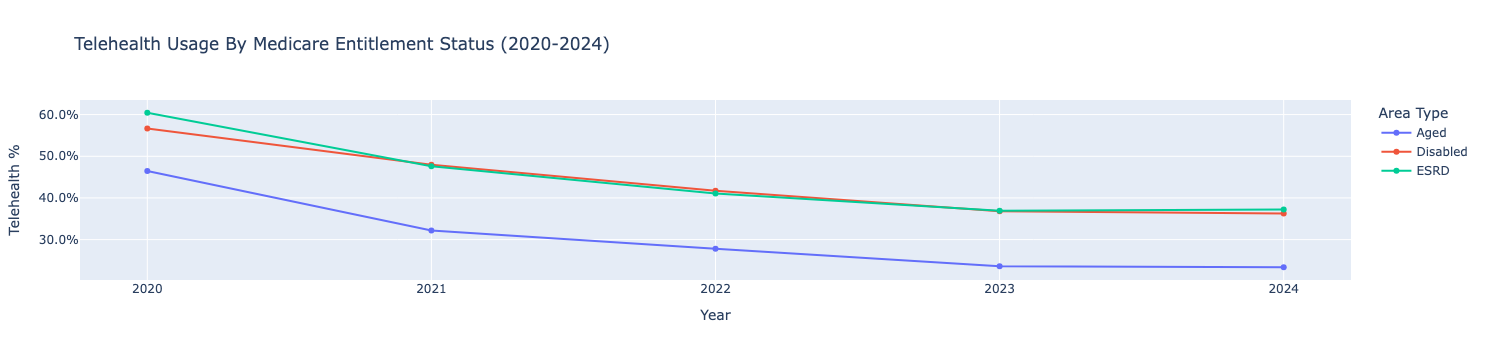

In [42]:
fig = px.line(
    df_Mdcr_Entlmt,
    x='Year',
    y='Pct_Telehealth',
    color='Bene_Mdcr_Entlmt_Stus',
    markers=True,
    labels={
        'Pct_Telehealth': 'Telehealth %',
        'Bene_Mdcr_Entlmt_Stus': 'Medicare Entitlement Status',
        'Year': 'Year'
    },
    title='Telehealth Usage By Medicare Entitlement Status (2020-2024)'
)

fig.update_layout(
    yaxis_tickformat='.1%',   # format as percentage
    legend_title='Area Type'
)

fig.update_layout(
    yaxis_tickformat='.1%',
    legend_title='Area Type',
    xaxis=dict(
        tickmode='linear',
        tick0=2020,
        dtick=1,
        tickformat='d'      
    )
)


fig.show()


Medicare entitlement is available to three basic groups of
"insured individuals" - the Aged, the Disabled, and those with end
stage renal disease (ESRD). Medicare entitlement can change
over time for beneficiaries that were initially entitled to Medicare
because of disability or ESRD before the age of 65. For purposes
of this reporting, beneficiaries who at any time during the
snapshot time period had ESRD, were Aged with ESRD or were
Disabled with ESRD are classified as ESRD; otherwise beneficiaries
are classified as Disabled or Aged.
Telehealth usage was highest among the Aged and Disabled populations. 

In [43]:
import statsmodels.formula.api as smf

# Build a dataset with one row per demographic combination at national level
df_model = df[
    (df['Bene_Geo_Desc'] == 'National') &
    (df['quarter'] == 'Overall') &
    (df['Year'] == 2024)
].copy()

df_model['Pct_Telehealth'] = pd.to_numeric(df_model['Pct_Telehealth'], errors='coerce')

# Run regression with all demographic factors
model = smf.ols(
    'Pct_Telehealth ~ Bene_Race_Desc + Bene_Sex_Desc + Bene_RUCA_Desc + Bene_Age_Desc + Bene_Mdcr_Entlmt_Stus',
    data=df_model
).fit()

print(model.summary())


                            OLS Regression Results                            
Dep. Variable:         Pct_Telehealth   R-squared:                       0.706
Model:                            OLS   Adj. R-squared:                  0.653
Method:                 Least Squares   F-statistic:                     13.35
Date:                Thu, 23 Apr 2026   Prob (F-statistic):           2.61e-17
Time:                        20:45:12   Log-Likelihood:                 210.97
No. Observations:                 106   AIC:                            -387.9
Df Residuals:                      89   BIC:                            -342.7
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                                                      coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------

Medicare entitlement status (ESRD/Disabled) and age are the strongest predictors of telehealth utilization, followed by rurality. Sex shows no significant independent effect once other factors are controlled for.
Caveats
	∙	Data is aggregated at the state/national level, not individual patient records, limiting causal inference
	∙	Analysis covers Medicare beneficiaries only and may not generalize to broader populations
	∙	Model shows signs of autocorrelation and non-normal residuals, so statistical results should be interpreted cautiously
	∙	Missing factors like broadband access and provider availability likely explain some of the remaining variation​​​​​​​​​​​​​​​​

In [44]:
!pip freeze | grep -E "pandas|folium|plotly|scipy|statsmodels|requests|jupyter"


folium==0.20.0
jupyter==1.1.1
jupyter-console==6.6.3
jupyter-events==0.12.0
jupyter-lsp==2.2.5
jupyter_client==8.6.3
jupyter_core==5.7.2
jupyter_server==2.15.0
jupyter_server_terminals==0.5.3
jupyterlab==4.3.5
jupyterlab_pygments==0.3.0
jupyterlab_server==2.27.3
jupyterlab_widgets==3.0.13
pandas==2.3.2
plotly==6.7.0
requests @ file:///home/conda/feedstock_root/build_artifacts/requests_1733217035951/work
scipy==1.16.3
statsmodels==0.14.5
